In [1]:
import magpylib as mp
import numpy as np
from src.bext.make_collection import make_polywell_collection, make_helmholtz_collection
import matplotlib.pyplot as plt

# Getting Fields From a Grid
This is a test validating the workflow of getting a field from a meshgrid

In [2]:
# make a collection object for a polywell
collection = make_polywell_collection(1e6, 1, 1.5) # I, Dia, Offset
#collection = mp.current.Circle(current=1e6, diameter=1).rotate_from_angax(90, [0, 1, 0])
#collection = make_helmholtz_collection(1e6, 1, 1.5)
# make a 3D meshgrid
_x = np.linspace(-3, 3, 100)
_y = np.linspace(-3, 3, 100)
_z = np.linspace(-3, 3, 100)
mg = np.meshgrid(_x, _y, _z, indexing='ij')
mg = np.moveaxis(mg, 0, -1)
B = collection.getB(mg)

mp.show(collection)

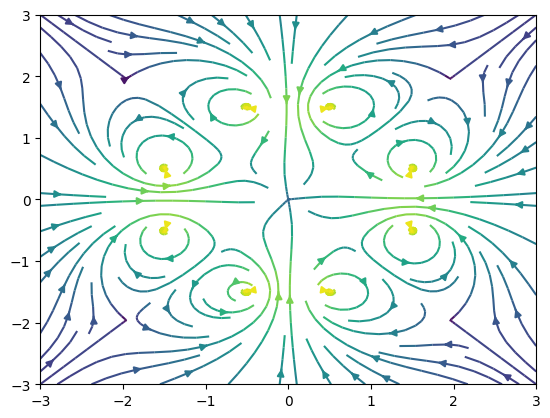

In [3]:
Bx, By, Bz = np.moveaxis(B, -1, 0) # split the B-field components

ind = 50
# plot a streamline of the XZ plane at y=0
fig, ax = plt.subplots()
ax.streamplot(_x, _z, Bx[:, ind, :].T, Bz[:, ind, :].T, color=np.log(np.linalg.norm(B, axis=3)[:, ind, :]).T)

plt.show()


Remember that the matplotlib streamline plot expects the U and V parameters (which give the direction of the arrows) to be Y-axis first, then X-axis. This means that if you are working with 'ij' indexing like a regular, sane person, you must transpose the corresponding arrays when calling the streamplot function.